In [14]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import random
import numpy as np

# Basic stats

In [6]:
base_path = "data/raw-img/"
class_counts = {}

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        class_counts[folder] = len(os.listdir(folder_path))

print(f"number of classes: {len(class_counts)}")
print(f"sum of all images: {sum(class_counts.values())}")
print("\nnumber of images in each class")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

number of classes: 10
sum of all images: 26179

number of images in each class
butterfly: 2112
cat: 1668
chicken: 3098
cow: 1866
dog: 4863
elephant: 1446
horse: 2623
sheep: 1820
spider: 4821
squirrel: 1862


# Class visualization

We printed histogram to better see the difference between classes. We can see that some of the classes have almost 5 000 images, whereas some have roughly 1 500 images. We know that we will definitely need to do something about the class imbalance, but we are not yet done with our EDA. 

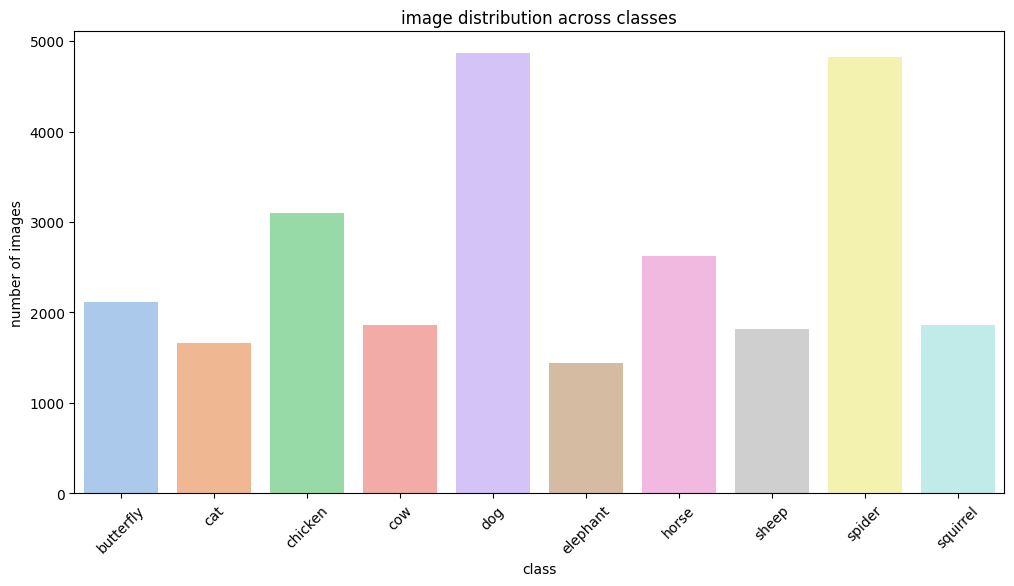

In [13]:
# convert to df because of sns
df = pd.DataFrame(list(class_counts.items()), columns=["class", "number of images"])

# print the graph
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="class", y="number of images", hue="class", palette="pastel", legend=False)
plt.xticks(rotation=45)
plt.xlabel("class")
plt.ylabel("number of images")
plt.title("image distribution across classes")
plt.show()

# Choose random images
We decided to pick and check some random images from all of the classes, but we also checked by manually looking at the images. We found out that some of the data is either wrongly annotated or should not be there at all, e.g.:
-  a picture of a horse in chicken foler,
-  child dressed as a spider in spider folder, 
-  people pointing at the wall where nothing can be seen (also spider folder), 
-  black people in white shirts in cow folder...

We roughly estimated the number of such images - it could be around 5-10% of data, depends on class. Some of them have more noise (chicken) than others (butterfly).

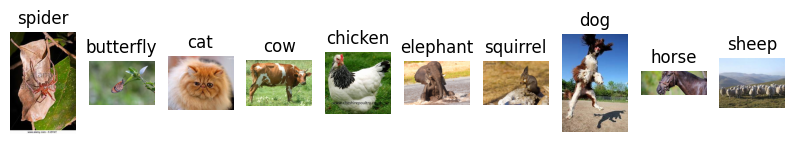

In [28]:
def show_sample_images(base_path, class_counts, n=10):
    plt.figure(figsize=(10, 10))
    
    classes = list(class_counts.keys())
    selected_classes = random.sample(classes, min(n, len(classes)))
    
    for i, cls in enumerate(selected_classes):
        folder_path = os.path.join(base_path, cls)
        images = os.listdir(folder_path)
        img_path = os.path.join(folder_path, random.choice(images))
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    
    plt.show()

show_sample_images(base_path, class_counts, n=10)

# Check image resolution
We found out that we have different image sizes across all of the classes and something will need to be done about this.

In [19]:
# for saving resolution
image_shapes = []

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        img_files = os.listdir(folder_path)[:10]  # choose 10 images from folder
        
        for img_file in img_files:
            img_path = os.path.join(folder_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                height, width = img.shape[:2]
                image_shapes.append([folder, img_file, width, height])

# dataframe conversion for better readability
df_shapes = pd.DataFrame(image_shapes, columns=["Class", "Image", "Width", "Height"])

# print unique resolutions
print(f"Unique image resolutions:\n {df_shapes[['Class', 'Width', 'Height']].drop_duplicates().values}")
print(df_shapes)

Unique image resolutions:
 [['butterfly' 426 640]
 ['butterfly' 640 457]
 ['butterfly' 425 640]
 ['butterfly' 640 454]
 ['butterfly' 640 426]
 ['butterfly' 640 439]
 ['butterfly' 640 416]
 ['butterfly' 640 375]
 ['cat' 300 210]
 ['cat' 300 188]
 ['cat' 150 150]
 ['cat' 300 169]
 ['cat' 200 300]
 ['cat' 300 200]
 ['cat' 288 216]
 ['cat' 300 218]
 ['chicken' 291 300]
 ['chicken' 247 300]
 ['chicken' 300 225]
 ['chicken' 300 169]
 ['chicken' 300 264]
 ['chicken' 300 173]
 ['chicken' 300 220]
 ['chicken' 254 300]
 ['cow' 300 200]
 ['cow' 300 225]
 ['cow' 300 214]
 ['cow' 300 213]
 ['cow' 300 199]
 ['dog' 300 225]
 ['dog' 300 214]
 ['dog' 153 300]
 ['dog' 300 101]
 ['dog' 300 182]
 ['dog' 205 300]
 ['dog' 251 300]
 ['dog' 200 300]
 ['elephant' 640 426]
 ['elephant' 640 424]
 ['elephant' 640 463]
 ['elephant' 640 349]
 ['elephant' 426 640]
 ['horse' 300 225]
 ['horse' 300 204]
 ['horse' 300 300]
 ['horse' 226 300]
 ['horse' 300 241]
 ['horse' 300 230]
 ['sheep' 640 480]
 ['sheep' 640 425]
 [

# Key findings

We found out, that:
- our classes are higly imbalanced (1.5k vs 5k images in different classes)
- some images are wrongly annotated, and we think that some of them should be deleted/moved to their corresponding folder
- high variance in image sizes

## What to do next?
We suggest to:
- Manually go over the folders and delete the image/move it to its corresponding folder. After this, we will see how much data is left
- Resize the images to a fixed size
- there will probably still be imbalance across the classes -> we suggest creating more datasets in various ways (oversampling, downsampling...) and testing it across various model architectures
- metrics we plan to use:
  - confusion matrix - to assess which classes are wrongly predicted
  - accuracy (not the best, but we can still use it)
  - recall
  - precision
  - f1
